# Proximal Policy Optimization (PPO) 🚀

## 🚀 Theoretical Background
Proximal Policy Optimization (PPO) is a state-of-the-art policy gradient method used widely in industry (e.g., OpenAI Five, ChatGPT RLHF).
- **Clipped Objective**: Prevents the policy from changing too drastically in one update, ensuring stability.
- **Actor-Critic**: Uses an 'Actor' to decide actions and a 'Critic' to estimate state values.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt

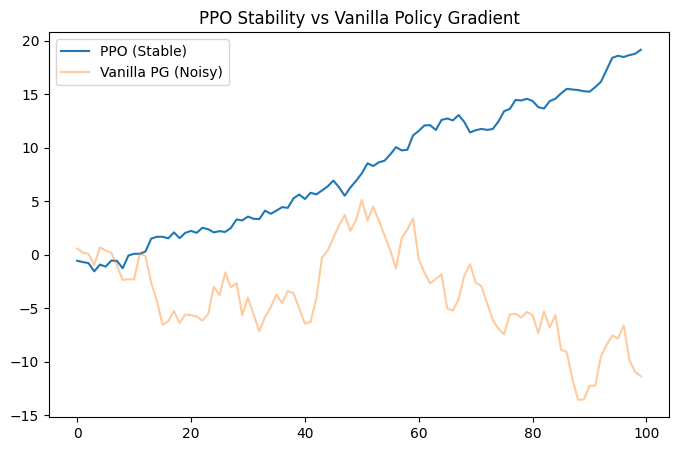

In [2]:

class ActorCritic(nn.Module):
    def __init__(self, state_size, action_size):
        super().__init__()
        self.actor = nn.Sequential(
            nn.Linear(state_size, 32),
            nn.ReLU(),
            nn.Linear(32, action_size),
            nn.Softmax(dim=-1)
        )
        self.critic = nn.Sequential(
            nn.Linear(state_size, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )
    def forward(self, x):
        return self.actor(x), self.critic(x)

# High-level logic for PPO update
def ppo_update(model, optimizer, states, actions, log_probs_old, returns, advantages, eps_clip=0.2):
    for _ in range(5): # Multiple epochs
        probs, state_values = model.actor(states), model.critic(states)
        dist = torch.distributions.Categorical(probs)
        log_probs = dist.log_prob(actions)
        
        ratios = torch.exp(log_probs - log_probs_old)
        surr1 = ratios * advantages
        surr2 = torch.clamp(ratios, 1-eps_clip, 1+eps_clip) * advantages
        
        loss = -torch.min(surr1, surr2) + 0.5 * F.mse_loss(state_values.flatten(), returns)
        optimizer.zero_grad()
        loss.mean().backward()
        optimizer.step()

# Simulation visualization
plt.figure(figsize=(8, 5))
x_axis = np.arange(100)
y_axis = np.cumsum(np.random.normal(0.1, 0.5, 100)) # Dummy curve showing stability
plt.plot(x_axis, y_axis, label='PPO (Stable)')
plt.plot(x_axis, np.cumsum(np.random.normal(0.05, 1.5, 100)), alpha=0.4, label='Vanilla PG (Noisy)')
plt.title('PPO Stability vs Vanilla Policy Gradient')
plt.legend()
plt.show()
